HOSPITAL DISEASE DIAGNOSIS DATASET


,Fever,Cough,Fatigue,Headache,Body_Pain,Age,Disease
0,1,1,1,1,1,45,Flu
1,1,1,0,1,0,32,Flu
2,1,0,1,0,1,60,Flu
3,0,1,1,1,1,25,Cold
4,0,0,0,0,0,18,Healthy
5,1,1,1,0,1,52,Flu
6,0,0,0,1,0,30,Healthy
7,1,1,1,1,1,65,Flu
8,1,1,1,0,0,40,Flu
9,0,0,0,0,0,22,Healthy



Dataset Shape: (40, 7)

Disease Classes:
['Cold' 'Flu' 'Healthy']

Training Samples: 28
Testing Samples: 12

NAIVE BAYES RESULTS
Accuracy: 50.0 %

Classification Report:

              precision    recall  f1-score   support

        Cold       0.00      0.00      0.00         2
         Flu       1.00      0.43      0.60         7
     Healthy       0.60      1.00      0.75         3

    accuracy                           0.50        12
   macro avg       0.53      0.48      0.45        12
weighted avg       0.73      0.50      0.54        12



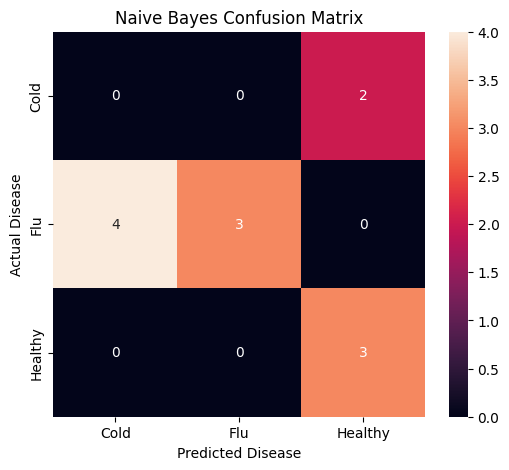

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/tmp/ipykernel_1630/2068798684.py:286: FutureWarning: `pgmpy.estimators.MaximumLikelihoodEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteMLE` instead.
  estimator = MaximumLikelihoodEstimator(



NEW PATIENT DIAGNOSIS - NAIVE BAYES
Predicted Disease: Flu

Disease Probabilities:
Cold: 0.05%
Flu: 99.95%
Healthy: 0.00%

BAYESIAN BELIEF NETWORK

Network Structure:
[('Disease', 'Fever'), ('Disease', 'Cough'), ('Disease', 'Fatigue'), ('Disease', 'Headache'), ('Disease', 'Body_Pain')]

Bayesian Belief Network trained successfully!
BBN Model Validation: SUCCESS

CONDITIONAL PROBABILITY DISTRIBUTIONS

 +------------------+-------+
| Disease(Cold)    | 0.175 |
+------------------+-------+
| Disease(Flu)     | 0.55  |
+------------------+-------+
| Disease(Healthy) | 0.275 |
+------------------+-------+

 +----------+--------------------+---------------------+------------------+
| Disease  | Disease(Cold)      | Disease(Flu)        | Disease(Healthy) |
+----------+--------------------+---------------------+------------------+
| Fever(0) | 0.7142857142857143 | 0.13636363636363635 | 1.0              |
+----------+--------------------+---------------------+------------------+
| Fever(1) | 0

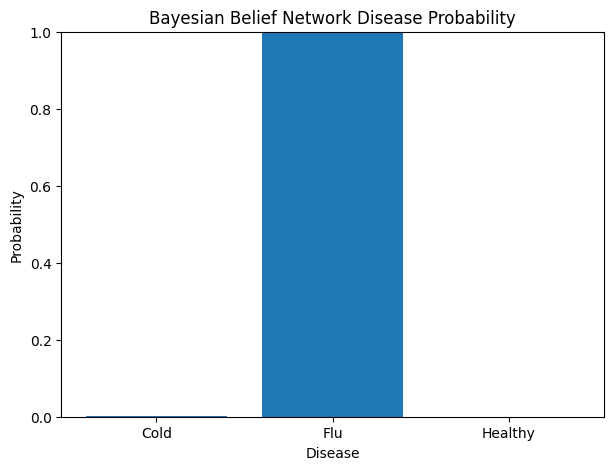


PROJECT CONCLUSION

1. Bayes' Theorem is used to calculate disease probabilities.

2. Naive Bayes predicts diseases using prior and conditional
   probabilities.

3. Bayesian Belief Networks represent dependencies between
   disease and patient symptoms.

4. Probability values allow the system to handle uncertainty.

5. The model can support doctors by providing probabilistic
   disease predictions.

6. Real-world systems require large clinical datasets,
   missing-data handling, validation, privacy protection,
   and medical expert verification.

NOTE:
This is an educational machine-learning model and should not
be used as a real medical diagnostic system.



In [17]:
# ============================================================
# HOSPITAL DISEASE DIAGNOSIS USING MACHINE LEARNING
# Naive Bayes + Bayesian Belief Network
# ============================================================

# Install pgmpy
!pip install -q pgmpy

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination


# ------------------------------------------------------------
# 2. CREATE HOSPITAL DATASET
# ------------------------------------------------------------

data = {
    'Fever': [
        1,1,1,0,0,1,0,1,1,0,
        0,1,1,0,0,1,0,1,0,1,
        1,0,1,0,1,0,1,1,0,0,
        1,1,0,0,1,0,1,1,0,0
    ],

    'Cough': [
        1,1,0,1,0,1,0,1,1,0,
        0,1,0,1,0,1,0,1,1,0,
        1,0,1,0,1,0,1,0,1,0,
        1,0,0,1,1,0,1,1,0,0
    ],

    'Fatigue': [
        1,0,1,1,0,1,0,1,1,0,
        1,1,0,1,0,1,0,1,0,1,
        1,0,1,0,1,0,1,1,0,0,
        1,0,1,1,0,1,0,1,0,0
    ],

    'Headache': [
        1,1,0,1,0,0,1,1,0,0,
        1,0,1,1,0,1,0,0,1,1,
        0,1,0,1,0,1,1,0,1,0,
        1,0,1,0,1,0,1,1,0,0
    ],

    'Body_Pain': [
        1,0,1,1,0,1,0,1,0,0,
        1,1,0,1,0,1,0,1,0,1,
        1,0,1,0,1,0,1,1,0,0,
        1,1,0,0,1,0,1,1,0,0
    ],

    'Age': [
        45,32,60,25,18,52,30,65,40,22,
        55,48,35,70,20,58,28,63,45,50,
        42,19,67,31,54,26,61,38,72,24,
        46,29,33,68,51,23,57,41,36,27
    ],

    'Disease': [
        'Flu','Flu','Flu','Cold','Healthy',
        'Flu','Healthy','Flu','Flu','Healthy',
        'Flu','Flu','Cold','Flu','Healthy',
        'Flu','Healthy','Flu','Cold','Flu',
        'Flu','Healthy','Flu','Cold','Flu',
        'Healthy','Flu','Flu','Cold','Healthy',
        'Flu','Cold','Healthy','Flu','Flu',
        'Healthy','Flu','Flu','Cold','Healthy'
    ]
}

df = pd.DataFrame(data)

print("======================================")
print("HOSPITAL DISEASE DIAGNOSIS DATASET")
print("======================================")

display(df.head(10))

print("\nDataset Shape:", df.shape)


# ------------------------------------------------------------
# 3. NAIVE BAYES CLASSIFICATION
# ------------------------------------------------------------

X = df.drop('Disease', axis=1)
y = df['Disease']

# Convert disease names into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nDisease Classes:")
print(label_encoder.classes_)


# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# ------------------------------------------------------------
# 5. TRAIN NAIVE BAYES MODEL
# ------------------------------------------------------------

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n======================================")
print("NAIVE BAYES RESULTS")
print("======================================")

print("Accuracy:", round(accuracy * 100, 2), "%")


# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 7. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Naive Bayes Confusion Matrix")

plt.show()


# ------------------------------------------------------------
# 8. NEW PATIENT PREDICTION USING NAIVE BAYES
# ------------------------------------------------------------

# Patient:
# Fever = 1
# Cough = 1
# Fatigue = 1
# Headache = 0
# Body Pain = 1
# Age = 45

new_patient = np.array([
    [1, 1, 1, 0, 1, 45]
])

prediction = nb_model.predict(new_patient)

probability = nb_model.predict_proba(new_patient)

predicted_disease = label_encoder.inverse_transform(prediction)

print("\n======================================")
print("NEW PATIENT DIAGNOSIS - NAIVE BAYES")
print("======================================")

print("Predicted Disease:", predicted_disease[0])

print("\nDisease Probabilities:")

for disease, prob in zip(
    label_encoder.classes_,
    probability[0]
):
    print(f"{disease}: {prob * 100:.2f}%")


# ------------------------------------------------------------
# 9. BAYESIAN BELIEF NETWORK
# ------------------------------------------------------------

print("\n======================================")
print("BAYESIAN BELIEF NETWORK")
print("======================================")


# Create Bayesian Network
# Disease influences symptoms.
# This represents conditional dependency.

model_bbn = DiscreteBayesianNetwork([
    ('Disease', 'Fever'),
    ('Disease', 'Cough'),
    ('Disease', 'Fatigue'),
    ('Disease', 'Headache'),
    ('Disease', 'Body_Pain')
])


print("\nNetwork Structure:")
print(list(model_bbn.edges()))


# ------------------------------------------------------------
# 10. PREPARE BBN DATA
# ------------------------------------------------------------

bbn_data = df[
    [
        'Disease',
        'Fever',
        'Cough',
        'Fatigue',
        'Headache',
        'Body_Pain'
    ]
].copy()

# Make sure symptom columns are integers
symptom_columns = [
    'Fever',
    'Cough',
    'Fatigue',
    'Headache',
    'Body_Pain'
]

for column in symptom_columns:
    bbn_data[column] = bbn_data[column].astype(int)


# ------------------------------------------------------------
# 11. TRAIN BBN
# ------------------------------------------------------------

# IMPORTANT:
# Initialize MaximumLikelihoodEstimator first.
# This fixes the pgmpy error.

estimator = MaximumLikelihoodEstimator(
    model_bbn,
    bbn_data
)

# Learn CPDs
cpds = estimator.get_parameters()

# Add learned CPDs to the network
model_bbn.add_cpds(*cpds)

print("\nBayesian Belief Network trained successfully!")


# ------------------------------------------------------------
# 12. CHECK BBN
# ------------------------------------------------------------

try:

    model_bbn.check_model()

    print("BBN Model Validation: SUCCESS")

except Exception as e:

    print("BBN Model Error:", e)


# ------------------------------------------------------------
# 13. DISPLAY CONDITIONAL PROBABILITY TABLES
# ------------------------------------------------------------

print("\n======================================")
print("CONDITIONAL PROBABILITY DISTRIBUTIONS")
print("======================================")

for cpd in model_bbn.get_cpds():

    print("\n", cpd)


# ------------------------------------------------------------
# 14. BBN DISEASE PREDICTION
# ------------------------------------------------------------

inference = VariableElimination(model_bbn)


# Symptoms of new patient
evidence = {

    'Fever': 1,
    'Cough': 1,
    'Fatigue': 1,
    'Headache': 0,
    'Body_Pain': 1

}


result = inference.query(
    variables=['Disease'],
    evidence=evidence
)


# ------------------------------------------------------------
# 15. DISPLAY BBN PROBABILITIES
# ------------------------------------------------------------

print("\n======================================")
print("BBN PROBABILISTIC DIAGNOSIS")
print("======================================")

for disease, probability in zip(
    result.state_names['Disease'],
    result.values
):

    print(
        f"{disease}: "
        f"{probability * 100:.2f}%"
    )


# ------------------------------------------------------------
# 16. MOST LIKELY DISEASE
# ------------------------------------------------------------

index = np.argmax(result.values)

most_likely_disease = result.state_names['Disease'][index]

most_likely_probability = result.values[index]


print("\n======================================")
print("FINAL DIAGNOSIS")
print("======================================")

print(
    "Most Likely Disease:",
    most_likely_disease
)

print(
    "Probability:",
    round(
        most_likely_probability * 100,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# 17. PLOT BBN PROBABILITIES
# ------------------------------------------------------------

diseases = result.state_names['Disease']
probabilities = result.values


plt.figure(figsize=(7,5))

plt.bar(
    diseases,
    probabilities
)

plt.xlabel("Disease")
plt.ylabel("Probability")
plt.title("Bayesian Belief Network Disease Probability")

plt.ylim(0, 1)

plt.show()


# ------------------------------------------------------------
# 18. FINAL SUMMARY
# ------------------------------------------------------------

print("\n======================================")
print("PROJECT CONCLUSION")
print("======================================")

print("""
1. Bayes' Theorem is used to calculate disease probabilities.

2. Naive Bayes predicts diseases using prior and conditional
   probabilities.

3. Bayesian Belief Networks represent dependencies between
   disease and patient symptoms.

4. Probability values allow the system to handle uncertainty.

5. The model can support doctors by providing probabilistic
   disease predictions.

6. Real-world systems require large clinical datasets,
   missing-data handling, validation, privacy protection,
   and medical expert verification.

NOTE:
This is an educational machine-learning model and should not
be used as a real medical diagnostic system.
""")